# Fractal dimention map

In [ ]:
import torch
import rasterio as rs
from pathlib import Path
from utils.fractal_map import fractal_dimension_map_2d
device = torch.device("cuda")


raster_path = Path(r"D:\ml_datasets\Chukotka\DEM\Линеаменты растр (полные)\растр линеаментов 120m.tif")
tensor = torch.tensor(rs.open(raster_path).read()).to(device)

torch.Size([1, 6253, 9277])

In [25]:
from torch.functional import F

patch_size = 64
pathces = tensor.squeeze(0).unfold(0, patch_size, patch_size).unfold(1, patch_size, patch_size)
pathces.shape

F.max_pool2d(pathces, kernel_size=(3,3))

RuntimeError: "max_pool2d_with_indices_out_cuda_frame" not implemented for 'Byte'

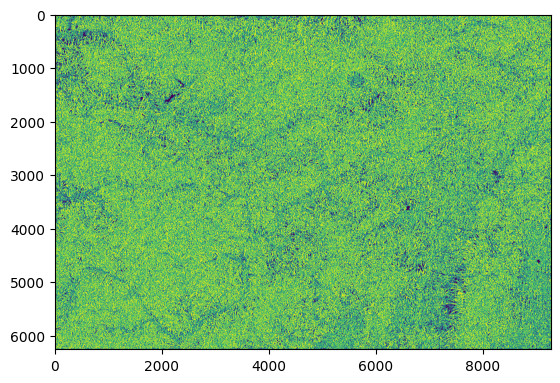

In [10]:
import matplotlib.pyplot as plt

plt.imshow(tensor.cpu()[0])

In [28]:
import torch
import torch.nn.functional as F

def fractal_dimension_map(image, patch_size=64, scales=None, threshold=0.0, debug=False):
    """
    Вычисляет карту фрактальной размерности методом box counting.

    Args:
        image (torch.Tensor): входное изображение формы (B, 1, H, W).
        patch_size (int): размер скользящего окна.
        scales (list): список размеров боксов (по умолчанию [1,2,4,8,16,32,64]).
        threshold (float): порог бинаризации.
        debug (bool): печатать размерности промежуточных тензоров.

    Returns:
        torch.Tensor: карта фрактальной размерности (B, 1, H, W).
    """
    if scales is None:
        scales = [1, 2, 4, 8, 16, 32, 64]

    B, C, H, W = image.shape
    assert C == 1, "Метод работает с одноканальными изображениями"

    # Бинаризация
    x = (image > threshold).float()

    # Padding для центрированных окон
    pad = patch_size // 2
    x_pad = F.pad(x, (pad, pad, pad, pad), mode='reflect')

    # Извлечение всех патчей с шагом 1
    patches_flat = F.unfold(x_pad, kernel_size=patch_size, stride=1)
    L_h = H + 2 * pad - patch_size + 1  # = H+1
    L_w = W + 2 * pad - patch_size + 1  # = W+1
    patches_flat = patches_flat.view(B, C, patch_size, patch_size, L_h, L_w)
    patches_flat = patches_flat[:, :, :, :, :H, :W]  # убираем лишние позиции

    # Переставляем в (B, H, W, C, patch_size, patch_size)
    patches = patches_flat.permute(0, 4, 5, 1, 2, 3).contiguous()
    patches = patches.view(-1, C, patch_size, patch_size)  # (B*H*W, 1, 64, 64)

    num_patches = patches.shape[0]
    num_scales = len(scales)

    if debug:
        print(f"Всего патчей: {num_patches}")

    # Маска пустых патчей
    patch_sum = patches.view(num_patches, -1).sum(dim=1)
    empty_mask = (patch_sum == 0)
    non_empty = ~empty_mask

    # Логарифмы масштабов
    log_scales = torch.log(torch.tensor(scales, dtype=torch.float, device=image.device))
    mean_log_scale = log_scales.mean()
    log_scale_centered = log_scales - mean_log_scale
    var_scale = (log_scale_centered**2).sum() / (num_scales - 1)  # скаляр

    # Сбор log(N) для каждого масштаба
    log_N_list = []
    for s in scales:
        pooled = F.max_pool2d(patches, kernel_size=s, stride=s)
        N_s = (pooled > 0).float().sum(dim=(-2, -1))
        log_N_s = torch.log(N_s + 1e-10)
        log_N_list.append(log_N_s)

    log_N = torch.stack(log_N_list, dim=1)  # (num_patches, num_scales)

    if debug:
        print(f"log_N shape: {log_N.shape}")

    # Инициализируем результат нулями
    slope = torch.zeros(num_patches, device=image.device)

    if non_empty.any():
        log_N_nonempty = log_N[non_empty]  # (n, num_scales)

        # Центрирование
        mean_log_N = log_N_nonempty.mean(dim=1, keepdim=True)
        log_N_centered = log_N_nonempty - mean_log_N  # (n, num_scales)

        # Ковариация между log_scale и log_N для каждого патча
        # Правильно: сумма по масштабам произведений центрированных величин, делённая на (num_scales-1)
        cov = (log_scale_centered.unsqueeze(0) * log_N_centered).sum(dim=1) / (num_scales - 1)
        # cov теперь (n,)

        if debug:
            print(f"cov shape: {cov.shape}")

        # Наклон (фрактальная размерность)
        slope_nonempty = cov / var_scale  # (n,)

        if debug:
            print(f"slope_nonempty shape: {slope_nonempty.shape}")

        # Присваиваем непустым патчам
        slope[non_empty] = slope_nonempty

    # Возвращаем к исходной пространственной форме
    slope = slope.view(B, H, W).unsqueeze(1)  # (B, 1, H, W)

    return slope


# Пример использования с отладкой
if __name__ == "__main__":
    H, W = 128, 128
    image = torch.rand(1, 1, H, W) > 0.5
    image = image.float()

    fd_map = fractal_dimension_map(image, patch_size=64, debug=True)
    print(f"Размер карты: {fd_map.shape}")
    print(f"Диапазон значений: {fd_map.min().item():.3f} - {fd_map.max().item():.3f}")

Всего патчей: 16384
log_N shape: torch.Size([16384, 7, 1])
cov shape: torch.Size([16384, 7])
slope_nonempty shape: torch.Size([16384, 7])


RuntimeError: shape mismatch: value tensor of shape [16384, 7] cannot be broadcast to indexing result of shape [16384]